In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm import camels

jax.devices("gpu")

[cuda(id=0)]

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## Loading the snapshots

In [4]:
# i_snapshots=range(1, 33+4, 4)
i_snapshots=[-2,-1]

In [5]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"

sim_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_088.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 2/2 [00:23<00:00, 11.93s/it]


In [6]:
def normalized_paint(positions, weights):
    N_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_N = cic_read(N_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_N)

def plot_field(field, ax, vlims=None):
    # log_sum = jnp.log10(field.sum(axis=0))
    log_sum = jnp.arcsinh(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims

    ax.set_xticks([])
    ax.set_yticks([])
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum


# velocity dispersion

In [7]:
i = -1
gas_pos = sim_dict["gas_poss"][i]
gas_vel = sim_dict["gas_vels"][i]

# particle count
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

In [8]:
# for vector fields
vcic_paint = jax.vmap(cic_paint, in_axes=(None, None, -1), out_axes=-1)
vcic_read = jax.vmap(cic_read, in_axes=(-1, None), out_axes=-1)

# mean velocity per voxel
vel_mean_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])
# per particle
gas_vel_mean = vcic_read(vel_mean_gas, gas_pos)
gas_vel_disp = jnp.sum((gas_vel_mean - gas_vel)**2, axis=-1)

In [9]:
# for vector fields
vcic_paint = jax.vmap(cic_paint, in_axes=(None, None, -1), out_axes=-1)
vcic_read = jax.vmap(cic_read, in_axes=(-1, None), out_axes=-1)

# mean velocity per voxel
vel_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel)
vel_mean_gas = vel_gas/N_gas[...,jnp.newaxis]
# per particle
gas_vel_mean = vcic_read(vel_mean_gas, gas_pos)
gas_vel_disp = jnp.sum((gas_vel_mean - gas_vel)**2, axis=-1)

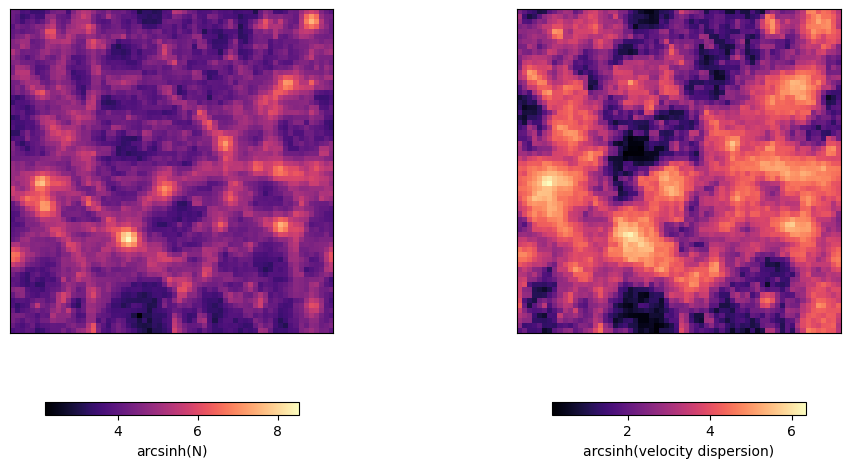

In [10]:
vel_disp_gas = normalized_paint(gas_pos, gas_vel_disp)
# vel_disp_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=gas_vel_disp/gas_N)

fig, ax = plt.subplots(figsize=(2*6, 6), ncols=2)

im, _, _ = plot_field(N_gas, ax[0])
fig.colorbar(im, ax=ax[0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)

im, _, _ = plot_field(vel_disp_gas, ax[1])
fig.colorbar(im, ax=ax[1], label="arcsinh(velocity dispersion)", orientation="horizontal", shrink=0.6, aspect=20)

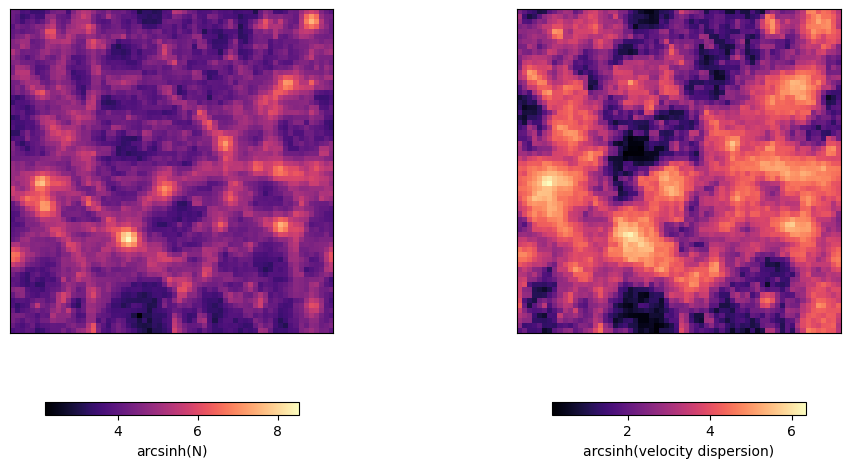

In [11]:
vel_disp_gas = normalized_paint(gas_pos, gas_vel_disp)
# vel_disp_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=gas_vel_disp/gas_N)

fig, ax = plt.subplots(figsize=(2*6, 6), ncols=2)

im, _, _ = plot_field(N_gas, ax[0])
fig.colorbar(im, ax=ax[0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)

im, _, _ = plot_field(vel_disp_gas, ax[1])
fig.colorbar(im, ax=ax[1], label="arcsinh(velocity dispersion)", orientation="horizontal", shrink=0.6, aspect=20)

# velocity divergence

In [12]:
kvec = fftk(mesh_shape)

# particle -> field (which is again the mean)
vel_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])
# vel_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel)
vel_gas_k = jnp.fft.rfftn(vel_gas, axes=(0,1,2))

# derivative in fourier space
gas_vel_div = [cic_read(jnp.fft.irfftn(gradient_kernel(kvec, i) * vel_gas_k[...,i]), gas_pos) for i in range(len(kvec))]
gas_vel_div = jnp.stack(gas_vel_div, axis=-1)
gas_vel_div = jnp.sum(gas_vel_div, axis=-1)

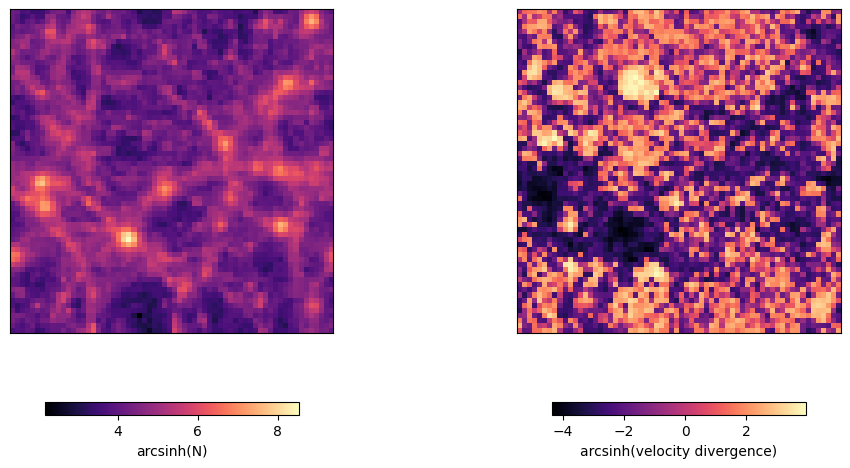

In [13]:
vel_div_gas = normalized_paint(gas_pos, gas_vel_div)
# vel_div_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=gas_vel_div/gas_N)

fig, ax = plt.subplots(figsize=(2*6, 6), ncols=2)

im, _, _ = plot_field(N_gas, ax[0])
fig.colorbar(im, ax=ax[0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)

im, _, _ = plot_field(vel_div_gas, ax[1])
fig.colorbar(im, ax=ax[1], label="arcsinh(velocity divergence)", orientation="horizontal", shrink=0.6, aspect=20)

# comments

In [14]:
# normalizing on the field-level
vel_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel)
vel_mean_gas_1 = vel_gas/N_gas[...,jnp.newaxis]

# normalizing on the particle-level
vel_mean_gas_2 = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])

print(jnp.allclose(vel_mean_gas_1, vel_mean_gas_2))

# is identical except for division by zero

False


# trash

In [15]:
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

vel_gas = jax.vmap(
    cic_paint, 
    in_axes=(None, None, -1),
    out_axes=-1,
)(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])

vel_gas = jnp.sum(vel_gas, axis=-1)

# mean_vel_gas = vel_gas/N_gas
# gas_mean_vel = 

In [16]:
vel_gas.shape

(64, 64, 64)

In [17]:
vel_gas.max()

Array(31.719936, dtype=float32)

In [18]:
vel_gas.min()

Array(-28.01307, dtype=float32)

In [19]:
jnp.arcsinh(vel_gas).min(), jnp.arcsinh(vel_gas).max()

(Array(-4.026137, dtype=float32), Array(4.150341, dtype=float32))

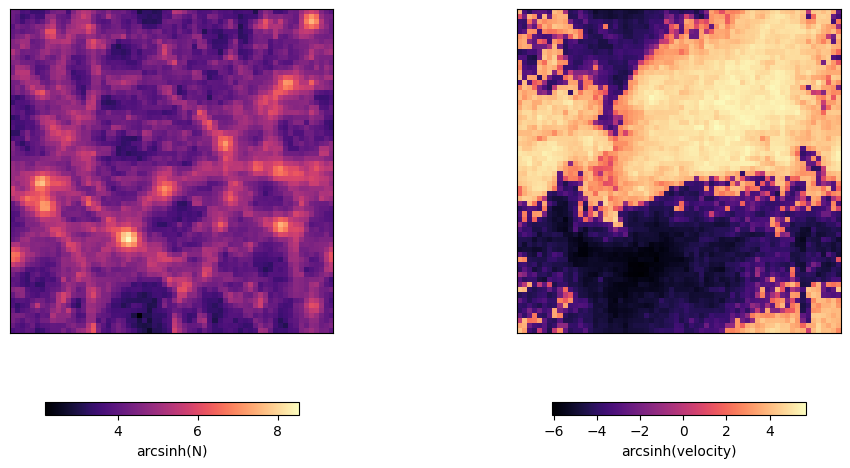

In [20]:
fig, ax = plt.subplots(figsize=(2*6, 6), ncols=2)

im, _, _ = plot_field(N_gas, ax[0])
fig.colorbar(im, ax=ax[0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)

im, _, _ = plot_field(vel_gas, ax[1])
fig.colorbar(im, ax=ax[1], label="arcsinh(velocity)", orientation="horizontal", shrink=0.6, aspect=20)